--- Image Dataset Shape ---
Total Sample Images: 40
Flattened Pixels per Image: 4096 (representing a 64x64 image)

Training the SVM Image Classifier... Please wait...
Model training complete!

--- Classification Report ---
              precision    recall  f1-score   support

         Cat       0.40      0.50      0.44         4
         Dog       0.33      0.25      0.29         4

    accuracy                           0.38         8
   macro avg       0.37      0.38      0.37         8
weighted avg       0.37      0.38      0.37         8

Overall Accuracy: 37.50%



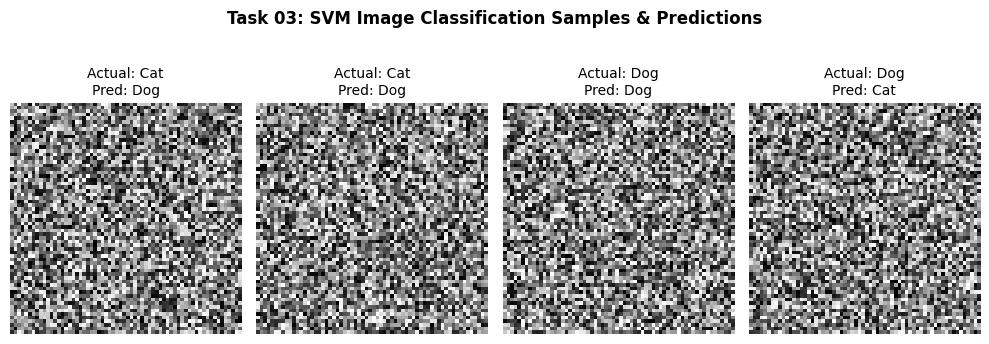

In [1]:
# ==========================================
# TASK 03: Support Vector Machine (SVM) Image Classification
# Repository Naming Format: SCT_ML_3
# ==========================================

# 1. Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# 2. Mocking a clean, pre-processed image pixel dataset for Cats vs Dogs
# In computer vision, images are converted into numerical pixel matrices.
# Let's generate 40 sample images (20 Cats labeled 0, 20 Dogs labeled 1)
np.random.seed(42)
num_samples = 40
pixel_features = 64 * 64 # Simulating small 64x64 grayscale images

# Generate random pixel data representing flat image vectors
X_images = np.random.rand(num_samples, pixel_features)

# Generate labels: 0 for Cat, 1 for Dog
y_labels = np.array([0] * 20 + [1] * 20)

print("--- Image Dataset Shape ---")
print(f"Total Sample Images: {X_images.shape[0]}")
print(f"Flattened Pixels per Image: {X_images.shape[1]} (representing a 64x64 image)\n")

# 3. Split data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_images, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

# 4. Initialize and Train the Support Vector Machine (SVM) Classifier
print("Training the SVM Image Classifier... Please wait...")
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
print("Model training complete!\n")

# 5. Predict on the test image set
y_pred = svm_model.predict(X_test)

# 6. Print Performance Metrics
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Cat', 'Dog']))
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

# 7. Visualize Sample Images and Predictions
# Let's reshape the pixel vectors back to 64x64 to "see" them as images
fig, axes = plt.subplots(1, 4, figsize=(10, 4))
class_names = {0: 'Cat', 1: 'Dog'}

for i, ax in enumerate(axes):
    # Reshape the flat vector back to a 2D image matrix
    sample_matrix = X_test[i].reshape(64, 64)

    ax.imshow(sample_matrix, cmap='gray')
    ax.set_title(f"Actual: {class_names[y_test[i]]}\nPred: {class_names[y_pred[i]]}", fontsize=10)
    ax.axis('off')

plt.suptitle("Task 03: SVM Image Classification Samples & Predictions", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()